In [ ]:
import numpy as np
import pandas as pd
import torch
from transformers import BertForSequenceClassification, BertTokenizer
import os
from collections import Counter


In [ ]:
!unzip /content/SenWave-BERT.zip

Archive:  /content/SenWave-BERT.zip
   creating: SenWave-BERT/
  inflating: SenWave-BERT/config.json  
  inflating: SenWave-BERT/model.safetensors  
  inflating: SenWave-BERT/training_args.bin  


# Load fine tuned Bert model

In [ ]:
model_path = "/content/SenWave-BERT/"
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained(model_path)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits)

        predicted_labels = (probs > 0.5).int()  # multilabel predictions

        predicted_labels_list = []
        for i, val in enumerate(predicted_labels[0]):
            if val == 1:
                label = model.config.id2label[i]
                predicted_labels_list.append(label)

        # if no labels are predicted (<.5) then just take argmax
        if not predicted_labels_list:
            predicted_label_idx = torch.argmax(probs, dim=-1).item()
            label = model.config.id2label[predicted_label_idx]
            return [label]

        return predicted_labels_list

# Labelling

In [ ]:
df = pd.read_csv("/content/transformed_final.csv", index_col=False)

In [ ]:
df

,tweets,cleaned,cleaned_transform,labels,batch,transformed_tweets_groq,groq_transformed,transformed_tweets_gemini,gemini_transformed,transformed_tweets_gpt,...,before_hatebert_pred,after_hatebert_pred_groq,after_hatebert_pred_gemini,after_hatebert_pred_gpt4o,after_hatebert_pred_deepseek,hate_keyword_before,hate_keyword_groq,hate_keyword_gemini,hate_keyword_gpt,hate_keyword_deepseek
0,b'If you bother to do the maths then in actual...,bother math actual fact socalled reformer isla...,if you bother to do the maths then in actual f...,Religion,1,"""If you take the time to do the math, you'll f...",1,A mathematical analysis reveals that those cla...,1,"""If you take the time to do the calculations, ...",...,1,1,1,1,1,0,0,0,0,0
1,"b'Muslims be like: The Quran is true, it says ...",muslim like quran true say quran,muslims be like the quran is true it says so i...,Religion,1,"""I'm fascinated by the Quran's teachings and t...",1,Some Muslims express their faith by citing the...,1,"""Some Muslims believe that the Quran is true b...",...,1,1,1,1,1,0,0,0,0,0
2,That painting by Jim Carrey of Sharia Huckabal...,painting jim carrey sharia huckabaloney spitti...,that painting by jim carrey of sharia huckabal...,Religion,1,"""I'm struck by Jim Carrey's depiction of Shari...",1,I find Jim Carrey's painting to be a striking ...,1,"""That painting by Jim Carrey captures a striki...",...,1,1,1,1,1,0,0,0,0,0
3,"b""So I say.. fck Islam it should be banned in ...",say fck islam banned uk go belief womens right,so i say fck islam it should be banned in the ...,Religion,1,"""I believe Islamic laws and beliefs often clas...",1,I believe that certain Islamic practices confl...,1,"""I believe there should be a discussion about ...",...,1,1,1,1,1,0,0,0,0,0
4,"b""Theresa May has her head so far up the Musla...",theresa may head far muslamic as doesnt need s...,theresa may has her head so far up the muslami...,Religion,1,"""Concerned about PM Theresa May's response to ...",1,I strongly disagree with Theresa May's policies.,1,"""Theresa May seems to have strong alignment wi...",...,1,1,1,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,b'Why does this Globalist Pope meddle in suppo...,globalist pope meddle supporting muslim invasi...,why does this globalist pope meddle in support...,Disciminatory,20,"""I'm concerned about the Pope's influence on g...",1,I question the Pope's focus on supporting Musl...,1,"""Why does this globalist Pope focus on support...",...,1,1,1,1,1,0,0,0,0,0
396,b'RT @BeckysTidePods: FLASHBACK: for the selec...,flashback selective memory whining hypocrite b...,flashback for the selective memory whining hyp...,Disciminatory,20,"""Remembering the contrast between past actions...",1,"Reflecting on past events, it's worth remember...",1,"""Flashback for those with selective memory: Th...",...,1,1,1,1,1,0,0,0,0,0
397,b'RT @chriscol22nd: Illinois: Two Muslims indi...,illinois two muslim indicted spying behalf ira...,illinois two muslims indicted for spying on be...,Disciminatory,20,"""Breaking: Two individuals in Illinois have be...",1,Two individuals in Illinois have been indicted...,1,"""Two individuals in Illinois have been indicte...",...,1,1,1,1,1,0,0,0,0,0
398,b'@najwazebian Wishing all young Lebanese fema...,wishing young lebanese female teacher living l...,wishing all young lebanese female teachers liv...,Disciminatory,20,"""Wishing all young Lebanese female teachers li...",1,Wishing all young Lebanese female teachers in ...,1,"""Wishing all young Lebanese female teachers li...",...,1,1,1,1,1,0,0,0,0,0


In [ ]:
df.columns

Index(['tweets', 'cleaned', 'cleaned_transform', 'labels', 'batch',
       'transformed_tweets_groq', 'groq_transformed',
       'transformed_tweets_gemini', 'gemini_transformed',
       'transformed_tweets_gpt', 'gpt_transformed',
       'transformed_tweets_deepseek', 'deepseek_transformed',
       'before_hatebert_pred', 'after_hatebert_pred_groq',
       'after_hatebert_pred_gemini', 'after_hatebert_pred_gpt4o',
       'after_hatebert_pred_deepseek', 'hate_keyword_before',
       'hate_keyword_groq', 'hate_keyword_gemini', 'hate_keyword_gpt',
       'hate_keyword_deepseek'],
      dtype='object')

In [ ]:
columns = ['cleaned_transform', 'transformed_tweets_groq', 'transformed_tweets_gemini', 'transformed_tweets_gpt', 'transformed_tweets_deepseek']
summary = {}
for col in columns:
    all_labels = df[col].apply(lambda x: predict_sentiment(x))
    flat_labels = [label for labels in all_labels for label in labels]
    label_counts = Counter(flat_labels)
    summary[col] = label_counts

summary_df = pd.DataFrame(summary).fillna(0).astype(int).T
summary_df.index.name = "Model"

KeyboardInterrupt: 

In [ ]:
summary_df

In [ ]:
import numpy as np
from scipy.stats import entropy

# Original distribution
p = np.array([259,165,33,30,9,10,6,0], dtype=float)

models = {
    "Groq":      [145,55,190,36,5,8,5,1],
    "Gemini":    [163,59,118,73,15,18,6,1],
    "GPT":       [163,72,111,65,5,15,10,1],
    "Deepseek":  [164,58,133,54,6,13,15,0]
}

# Small epsilon to avoid log(0)
eps = 1e-10

# Normalize
p = (p + eps) / (p + eps).sum()

for name, vals in models.items():

    q = np.array(vals, dtype=float)
    q = (q + eps) / (q + eps).sum()

    kl = entropy(p, q)

    print(f"KL(cleaned_transform || {name}) = {kl:.4f}")

KL(cleaned_transform || Groq) = 0.4006
KL(cleaned_transform || Gemini) = 0.2886
KL(cleaned_transform || GPT) = 0.2274
KL(cleaned_transform || Deepseek) = 0.2903


In [ ]:
summary_df.to_csv("../../Dataset/tweets/sentiment.csv")

# Visualizations

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# set sns plot
sns.set_theme()
sns.set_theme(style="whitegrid")
sns.set_context("talk")
plt.rcParams['axes.facecolor'] = '#dce3e8'    # Plot area background
plt.rcParams['figure.facecolor'] = '#dce3e8'  # Outside plot area (whole figure)

In [ ]:
sentiment = pd.read_csv("/content/sentiment.csv")

In [ ]:
sentiment["Model"] = sentiment["Model"].replace({
    "cleaned_transform": "Before",
    "transformed_tweets_groq": "Groq",
    "transformed_tweets_gemini": "Gemini",
    "transformed_tweets_gpt": "GPT",
    "transformed_tweets_deepseek": "Deepseek"
})

In [ ]:
sentiment.drop(columns=['Official report'], inplace=True)

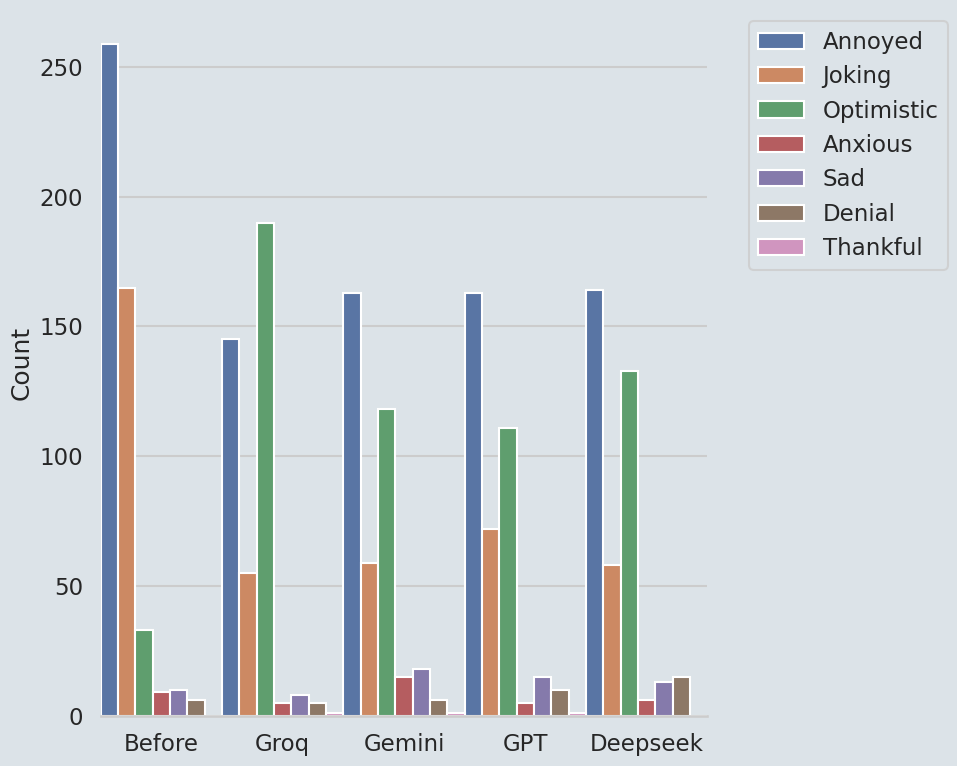

In [ ]:
s_melted = sentiment.melt(id_vars='Model', var_name='Sentiment', value_name='Count')
plt.figure(figsize=(10,8))
sns.barplot(data=s_melted, x='Model', y='Count', hue='Sentiment', width=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("")
sns.despine(left=True)
plt.tight_layout()
plt.show()

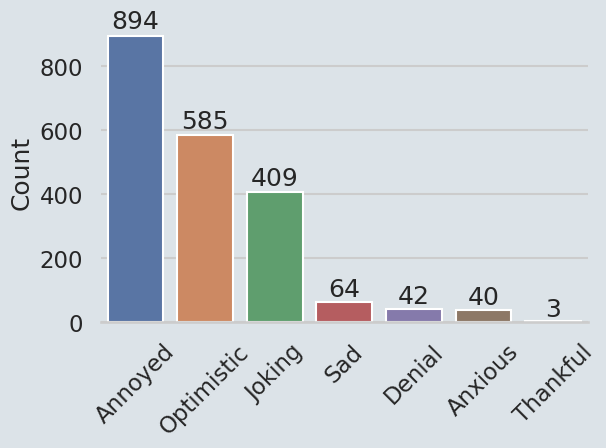

In [ ]:
sentiment_counts = s_melted.groupby("Sentiment")['Count'].sum().reset_index().sort_values("Count", ascending=False)
ax = sns.barplot(sentiment_counts, x="Sentiment", y="Count", hue="Sentiment")
plt.xticks(rotation=45)
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,  # x position
        height + 0.01 * height,         # y position (slightly above the bar)
        f'{int(height)}',               # text
        ha='center', va='bottom'        # alignment
    )
sns.despine(left=True)
plt.xlabel("")
plt.tight_layout()
plt.show()

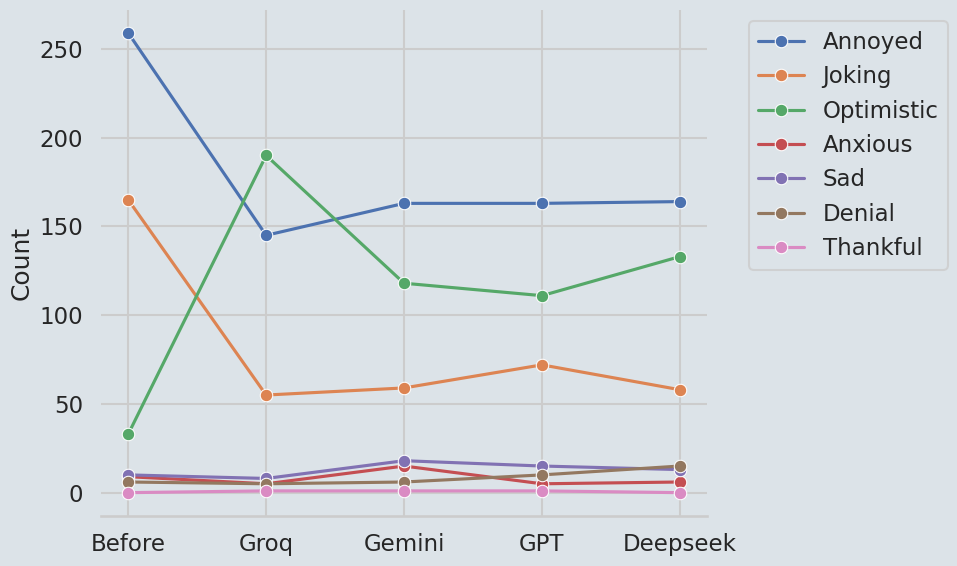

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=s_melted, x='Model', y='Count', hue='Sentiment', marker='o')
plt.grid(True)
sns.despine(left=True)
plt.xlabel("")
plt.legend(title=None, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

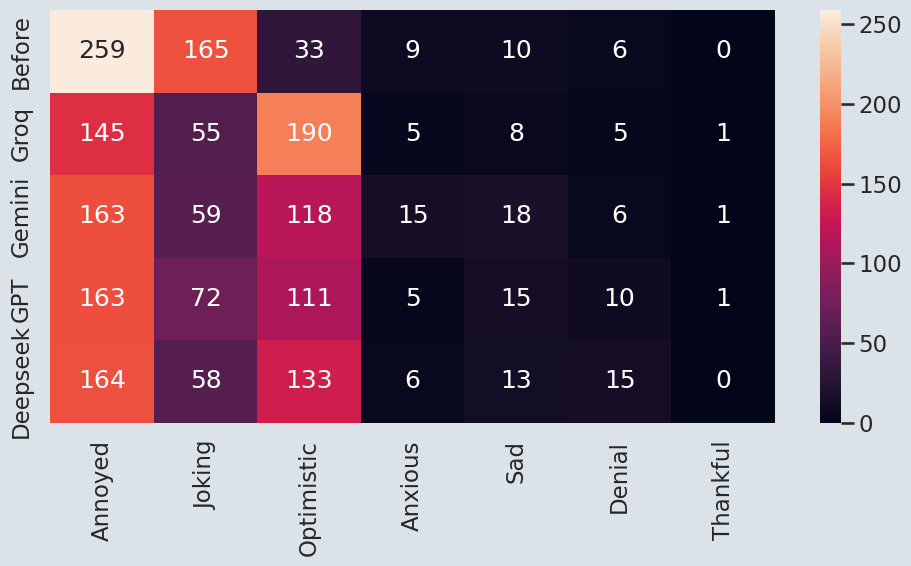

In [ ]:
plt.figure(figsize=(10,6))
heatmap_data = sentiment.drop(columns='Model')
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='rocket',
            yticklabels=sentiment['Model'])
plt.tight_layout()
plt.show()

# Semantic Analysis

In [ ]:
from sentence_transformers import SentenceTransformer
sentences = ["This is an example sentence", "Each sentence is converted"]

model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
embeddings = model.encode(sentences)
print(embeddings)

[[ 0.0225026  -0.07829182 -0.02303074 ... -0.00827928  0.02652692
  -0.00201897]
 [ 0.04170237  0.00109741 -0.01553419 ... -0.02181628 -0.06359357
  -0.00875285]]
